In [2]:
import csv
import os
import subprocess
from string import punctuation

import pandas as pd

import spacy
import spacy_transformers
from wordfreq import zipf_frequency


In [3]:
# calculate number of words in each word list
total_elements = 0
with open("raw-word-lists/English/English.txt", "r", encoding="utf-8") as file:
    csv_reader = csv.reader(file)
    for row in csv_reader:
        total_elements += len(row)
total_elements

466434

In [4]:
# Generalize the above code to calculate the number of words in each word list in the raw-word-lists directory

def count_csv_elements_in_file(file_path):
    total_elements = 0
    with open(file_path, "r", encoding="utf-8") as file:
        csv_reader = csv.reader(file)
        for row in csv_reader:
            total_elements += len(row)
    return total_elements

language = []
total_words = []
for path,subdirs,files in os.walk("raw-word-lists"):
    for name in files:
        file_name = (os.path.join(path, name))
        language += [name.split(".")[0]]
        total_words += [count_csv_elements_in_file(file_name)] 

df = pd.DataFrame({
    "language": language,
    "total_words": total_words
})
df

,language,total_words
0,Dutch,173556
1,Catalan,3585
2,German,1707903
3,Romanian,272616
4,Russian,171553
5,Italian,661563
6,English,466434
7,Greek,35279
8,Portuguese,1108873
9,Finnish,91672


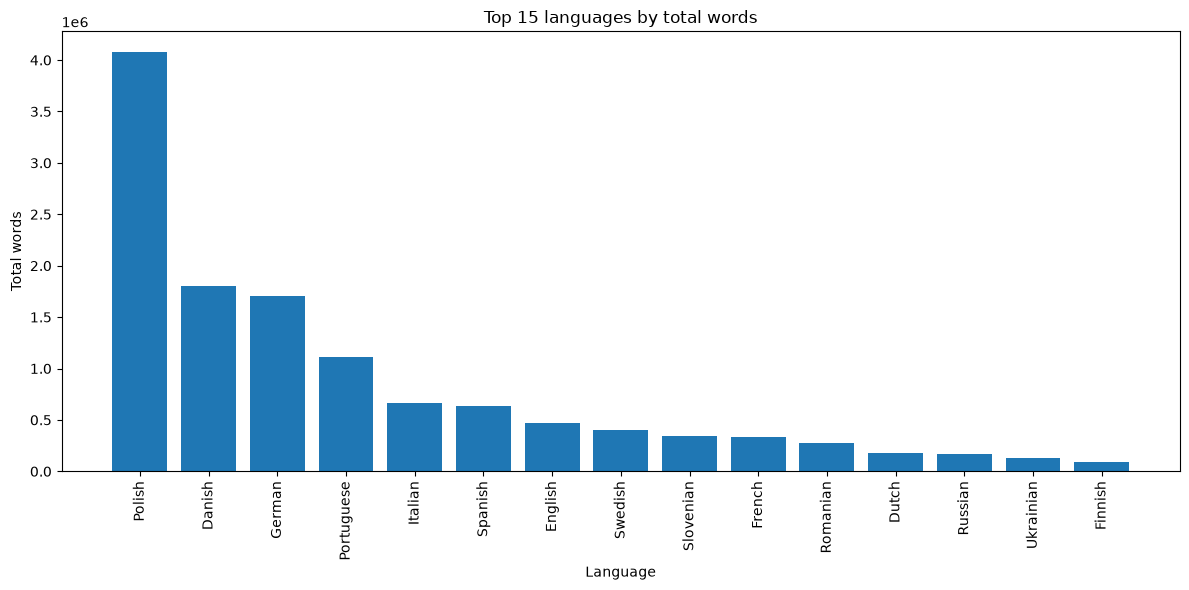

In [5]:
import matplotlib.pyplot as plt
df_sorted = df.sort_values("total_words", ascending=False)
top_n = min(15, len(df_sorted))
df_top = df_sorted.head(top_n)
plt.figure(figsize=(12, 6))
plt.bar(df_top["language"], df_top["total_words"])
plt.xticks(rotation=90)
plt.title(f"Top {top_n} languages by total words")
plt.xlabel("Language")
plt.ylabel("Total words")
plt.tight_layout()
plt.show()

In [6]:
spacy_models = {
    "Catalan": "ca_core_news_trf",
    "Croatian": "hr_core_news_lg",
    "Danish": "da_core_news_trf",
    "Dutch": "nl_core_news_lg",
    "English": "en_core_web_trf",
    "Finnish": "fi_core_news_lg",
    "French": "fr_dep_news_trf",
    "German": "de_dep_news_trf",
    "Greek": "el_core_news_lg",
    "Italian": "it_core_news_lg",
    "Lithuanian": "lt_core_news_lg",
    "Macedonian": "mk_core_news_lg",
    "Norwegian": "nb_core_news_lg",
    "Polish": "pl_core_news_lg",
    "Portuguese": "pt_core_news_lg",
    "Romanian": "ro_core_news_lg",
    "Russian": "ru_core_news_lg",
    "Slovenian": "sl_core_news_trf",
    "Spanish": "es_dep_news_trf",
    "Swedish": "sv_core_news_lg",
    "Ukrainian": "uk_core_news_trf"
}


Downloading English, Spanish, and German language models

In [23]:
for model in [spacy_models["English"], spacy_models["Spanish"], spacy_models["German"]]:
    result = subprocess.run(["python3", "-m", "spacy", "download", model], capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')

Checked 1 package in 23ms

✔ Download and installation successful
You can now load the package via spacy.load('es_dep_news_trf')

Resolved 15 packages in 2m 02s
 Downloaded es-dep-news-trf
Prepared 1 package in 2m 00s
Installed 1 package in 4ms
 + es-dep-news-trf==3.8.0 (from https://github.com/explosion/spacy-models/releases/download/es_dep_news_trf-3.8.0/es_dep_news_trf-3.8.0-py3-none-any.whl)

✔ Download and installation successful
You can now load the package via spacy.load('de_dep_news_trf')

Resolved 15 packages in 2m 03s
 Downloaded de-dep-news-trf
Prepared 1 package in 1m 55s
Installed 1 package in 2ms
 + de-dep-news-trf==3.8.0 (from https://github.com/explosion/spacy-models/releases/download/de_dep_news_trf-3.8.0/de_dep_news_trf-3.8.0-py3-none-any.whl)



In [8]:
try:
    os.mkdir("data")
except FileExistsError:
    pass

In [9]:
for language in spacy_models.keys():
    try:
        os.mkdir(f"data/{language}")
        print(f"Created directory: data/{language}")
    except FileExistsError:
        print(f"Directory already exists: data/{language}")

Directory already exists: data/Catalan
Directory already exists: data/Croatian
Directory already exists: data/Danish
Directory already exists: data/Dutch
Directory already exists: data/English
Directory already exists: data/Finnish
Directory already exists: data/French
Directory already exists: data/German
Directory already exists: data/Greek
Directory already exists: data/Italian
Directory already exists: data/Lithuanian
Directory already exists: data/Macedonian
Directory already exists: data/Norwegian
Directory already exists: data/Polish
Directory already exists: data/Portuguese
Directory already exists: data/Romanian
Directory already exists: data/Russian
Directory already exists: data/Slovenian
Directory already exists: data/Spanish
Directory already exists: data/Swedish
Directory already exists: data/Ukrainian


In [10]:
with open("raw-word-lists/English/English.txt", "r", encoding="utf-8") as f:
    word_list = f.read().split(",")
    
word_df = pd.DataFrame({"word": word_list})
word_df

,word
0,aardvark
1,aardvarks
2,aardwolf
3,aardwolves
4,Aaren
...,...
466429,Zwolle
466430,Zworykin
466431,ZZ
466432,zZt


In [11]:
def load_and_clean_word_list(language:str)->pd.DataFrame:
    with open(f"raw-word-lists/{language}/{language}.txt", "r", encoding="utf-8") as f:
        word_list = f.read().split(",")
    word_df = pd.DataFrame({"word": word_list})
    word_df["word"] = word_df["word"].str.strip(punctuation)
    return word_df


In [12]:
load_and_clean_word_list("English")

,word
0,aardvark
1,aardvarks
2,aardwolf
3,aardwolves
4,Aaren
...,...
466429,Zwolle
466430,Zworykin
466431,ZZ
466432,zZt


#### Lemmatization

In [24]:
nlp_models = {
    "English": spacy.load(spacy_models["English"], disable=["ner", "parser","textcat"]),
    "Spanish": spacy.load(spacy_models["Spanish"], disable=["ner", "parser","textcat"]),
    "German": spacy.load(spacy_models["German"], disable=["ner", "parser","textcat"])
}

In [14]:
def add_lemma(df:pd.DataFrame,
              nlp,
              batch_size:int=1000,)-> pd.DataFrame:
    docs = nlp.pipe(df["word"].tolist(), batch_size=batch_size)
    lemmas = [doc[0].lemma_ for doc in docs]
    df["lemma"] = pd.DataFrame(lemmas, index=df.index)
    return df

In [32]:
add_lemma(load_and_clean_word_list("English")[:100], nlp_models["English"])

,word,lemma
0,aardvark,aardvark
1,aardvarks,aardvarks
2,aardwolf,aardwolf
3,aardwolves,aardwolf
4,Aaren,Aaren
...,...,...
95,Abama,Abama
96,abamp,abamp
97,abampere,abampere
98,abamperes,abamperes


In [16]:
def add_word_frequencies(df:pd.DataFrame,language:str)-> pd.DataFrame:
    language_group = spacy_models[language].split("_")[0]
    df["zipf_freq_lemma"] = [zipf_frequency(w,language_group) for w in df["lemma"]]
    return df

In [ ]:
add_word_frequencies(add_lemma(load_and_clean_word_list("English")[:100], nlp_models["English"]), "English")

,word,lemma,zipf_freq_lemma
0,aardvark,aardvark,2.39
1,aardvarks,aardvarks,1.68
2,aardwolf,aardwolf,1.11
3,aardwolves,aardwolf,1.11
4,Aaren,Aaren,0.00
...,...,...,...
95,Abama,Abama,0.00
96,abamp,abamp,0.00
97,abampere,abampere,0.00
98,abamperes,abamperes,0.00


In [18]:
def clean_up_and_export(df: pd.DataFrame, language: str) -> None:
    df = (
        df.loc[df.groupby("lemma", sort=False)["zipf_freq_lemma"].idxmax()]
        .reset_index(drop=True)
    )

    df = df[(df["zipf_freq_lemma"] > 0)]

    df.loc[:, "word_difficulty"] = pd.cut(
        df["zipf_freq_lemma"],
        bins=[-float("inf"), 2.0, 4.0, float("inf")],
        labels=["advanced", "intermediate", "beginner"],
        include_lowest=True,
        right=True,
    )

    df = df.drop(columns=["word", "zipf_freq_lemma"])

    df = df.rename(
        columns={
            "lemma": "word"
        }
    )

    df.to_json(
        f"data/{language}/word-list-cleaned.json",
        orient="index"
    )

In [ ]:
clean_up_and_export(add_word_frequencies(add_lemma(load_and_clean_word_list("English")[:100], nlp_models["English"]), "English"), "English")

In [26]:
def create_clean_word_list(language:str, nlp_models: dict) -> None:
    nlp = nlp_models[language]
    
    print("load in dataset")
    lang_df = load_and_clean_word_list(language)
    
    print("Lemmatise words")
    lang_df = add_lemma(lang_df, nlp)
    
    print("Add the word frequencies")
    lang_df = add_word_frequencies(lang_df, language)
    
    print("Do the final clean up and export to the file")
    clean_up_and_export(lang_df, language)
    
    return None

In [27]:
for language in ["English", "Spanish", "German"]:
    print(f"\n=== Processing {language} ===")
    create_clean_word_list(language, nlp_models)


=== Processing English ===
load in dataset
Lemmatise words
Add the word frequencies
Do the final clean up and export to the file

=== Processing Spanish ===
load in dataset
Lemmatise words
Add the word frequencies
Do the final clean up and export to the file

=== Processing German ===
load in dataset
Lemmatise words
Add the word frequencies
Do the final clean up and export to the file


In [30]:
import json

language_raw = []
total_words_raw = []

for language in ["English", "Spanish", "German"]:
    file_name = f"raw-word-lists/{language}/{language}.txt"
    if os.path.exists(file_name):
        language_raw.append(language)
        total_words_raw.append(count_csv_elements_in_file(file_name))
        
raw_data = pd.DataFrame({
    "language": language_raw,
    "type": ["Raw"]*len(language_raw),
    "total_words_raw": total_words_raw
})

In [33]:
language_clean = []
total_words_clean = []

for language in ["English", "Spanish", "German"]:
    filename = f"data/{language}/word-list-cleaned.json"
    if os.path.exists(filename):
        language_clean.append(language)
        with open(filename, "r", encoding="utf-8") as f:
            data = json.load(f)
            total_words_clean.append(len(data.keys()))
            
clean_data = pd.DataFrame({
    "language": language_clean,
    "total_words_clean": total_words_clean,
})

# Merge on language column to avoid NaN values
result = pd.merge(raw_data, clean_data, on="language", how="outer")
result

,language,type,total_words_raw,total_words_clean
0,English,Raw,466434,111867
1,German,Raw,1707903,241709
2,Spanish,Raw,636598,75711


#### Language Learning Agent (ReAct Agent)